<a href="https://colab.research.google.com/github/SeEun-Kwon/data_analysis/blob/main/%EC%8B%A4%EC%8A%B52_%EA%B1%B4%EA%B0%95%EA%B2%80%EC%A7%84%EC%A0%95%EB%B3%B4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 한글 깨짐 방지 코드
import sys

# Google Colab 환경에서 실행 중인지 확인
if 'google.colab' in sys.modules:
    # debconf를 Noninteractive 모드로 설정
    !echo 'debconf debconf/frontend select Noninteractive' | \
    debconf-set-selections

    !sudo apt-get -qq -y install fonts-nanum      # fonts-nanum 패키지 설치
    import matplotlib.font_manager as fm          # Matplotlib의 폰트 매니저 가져오기
    font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])  # 나눔 폰트의 시스템 경로 찾기
    for fpath in font_files:                       # 찾은 각 나눔 폰트를 Matplotlib 폰트 매니저에 추가
        fm.fontManager.addfont(fpath)

plt.rcParams['font.family'] = 'NanumGothic'

In [ ]:
# 파이썬 ≥3.5
import sys
assert sys.version_info >= (3, 5)

# 사이킷런 ≥0.20
import sklearn
assert sklearn.__version__ >= "0.20"

# 공통 모듈 임포트
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import pandas as pd

path = '/content/국민건강보험공단_건강검진정보_2023.CSV'

df = pd.read_csv(path, encoding='cp949')    # 한글 인코딩의 한 종류, EUC-KR의 확장형

In [ ]:
df.head()

,기준년도,가입자일련번호,시도코드,성별코드,연령대코드(5세단위),신장(5cm단위),체중(5kg단위),허리둘레,시력(좌),시력(우),...,혈청지피티(ALT),감마지티피,흡연상태,음주여부,구강검진수검여부,치아우식증유무,결손치 유무,치아마모증유무,제3대구치(사랑니) 이상,치석
0,2023,34735,46,2,9,155,70,92.0,1.2,1.2,...,24.0,50.0,1.0,1.0,0,NaN,NaN,NaN,NaN,NaN
1,2023,4105118,11,1,17,160,55,86.0,0.9,9.9,...,11.0,31.0,1.0,1.0,0,NaN,NaN,NaN,NaN,NaN
2,2023,362482,36,2,13,150,65,96.0,1.0,0.8,...,29.0,24.0,1.0,1.0,0,NaN,NaN,NaN,NaN,NaN
3,2023,653166,11,1,13,160,70,85.0,1.0,1.2,...,21.0,27.0,3.0,1.0,1,0.0,NaN,NaN,NaN,0.0
4,2023,4152237,41,1,12,165,65,84.5,1.0,1.2,...,33.0,49.0,3.0,1.0,0,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.tail()

,기준년도,가입자일련번호,시도코드,성별코드,연령대코드(5세단위),신장(5cm단위),체중(5kg단위),허리둘레,시력(좌),시력(우),...,혈청지피티(ALT),감마지티피,흡연상태,음주여부,구강검진수검여부,치아우식증유무,결손치 유무,치아마모증유무,제3대구치(사랑니) 이상,치석
999995,2023,3265034,26,1,8,170,65,78.0,1.2,1.0,...,13.0,22.0,1.0,1.0,1,0.0,NaN,NaN,NaN,1.0
999996,2023,1421865,41,1,10,165,80,96.1,0.9,1.2,...,65.0,160.0,2.0,1.0,0,NaN,NaN,NaN,NaN,NaN
999997,2023,3889375,41,2,11,155,65,87.0,0.5,0.7,...,26.0,25.0,1.0,1.0,0,NaN,NaN,NaN,NaN,NaN
999998,2023,2618086,41,2,7,160,55,69.0,1.0,1.2,...,20.0,16.0,1.0,0.0,0,NaN,NaN,NaN,NaN,NaN
999999,2023,1279122,31,2,12,160,50,75.0,0.8,0.7,...,21.0,34.0,1.0,0.0,1,0.0,NaN,NaN,NaN,2.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 33 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   기준년도           1000000 non-null  int64  
 1   가입자일련번호        1000000 non-null  int64  
 2   시도코드           1000000 non-null  int64  
 3   성별코드           1000000 non-null  int64  
 4   연령대코드(5세단위)    1000000 non-null  int64  
 5   신장(5cm단위)      1000000 non-null  int64  
 6   체중(5kg단위)      1000000 non-null  int64  
 7   허리둘레           999589 non-null   float64
 8   시력(좌)          999816 non-null   float64
 9   시력(우)          999823 non-null   float64
 10  청력(좌)          999863 non-null   float64
 11  청력(우)          999862 non-null   float64
 12  수축기혈압          994253 non-null   float64
 13  이완기혈압          994253 non-null   float64
 14  식전혈당(공복혈당)     994186 non-null   float64
 15  총콜레스테롤         338606 non-null   float64
 16  트리글리세라이드       338606 non-null   float64
 17  HDL콜레스테롤 

In [ ]:
df.isnull().sum()

,0
기준년도,0
가입자일련번호,0
시도코드,0
성별코드,0
연령대코드(5세단위),0
신장(5cm단위),0
체중(5kg단위),0
허리둘레,411
시력(좌),184
시력(우),177


<Axes: >

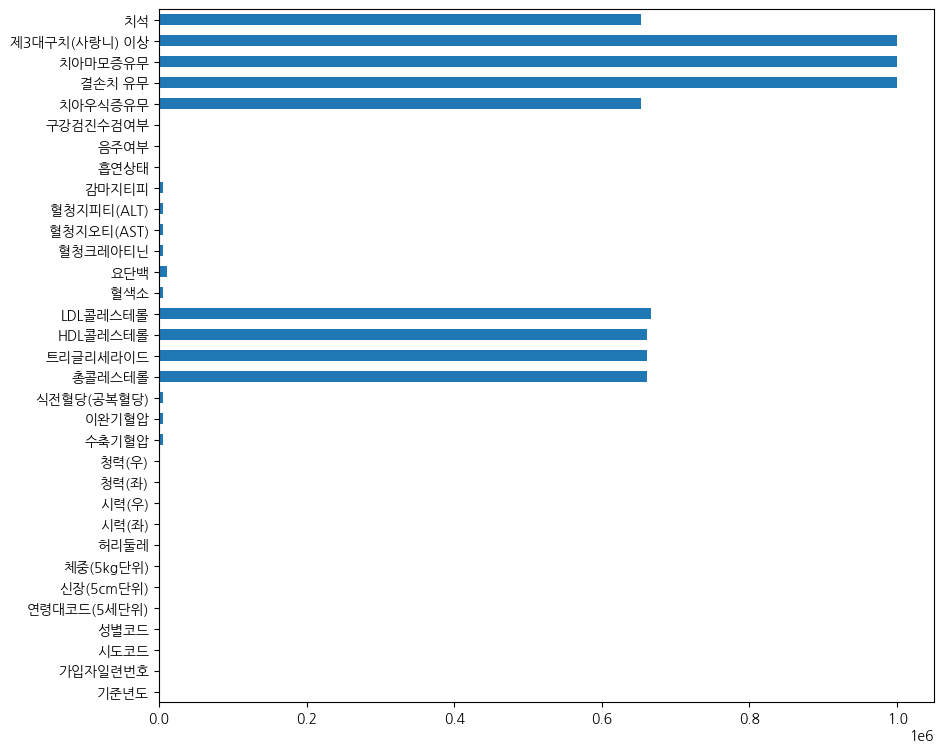

In [ ]:
df.isnull().sum().plot.barh(figsize=(10,9))

In [ ]:
# 결측값이 전체 표본의 과반수를 넘는 특성
# : 치석, 제3대구치(이상), 치아마모증유무, 결손치 유무, 치아우식증유무, LDL콜레스테롤, HDL콜레스테롤, 트리글리세라이드, 총콜레스테롤

missing_cols = ['치석', '제3대구치(사랑니) 이상', '치아마모증유무', '결손치 유무', '치아우식증유무', 'LDL콜레스테롤', 'HDL콜레스테롤', '트리글리세라이드', '총콜레스테롤']
df = df.drop(missing_cols, axis=1) # 0: index(row), 1: columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 24 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   기준년도         1000000 non-null  int64  
 1   가입자일련번호      1000000 non-null  int64  
 2   시도코드         1000000 non-null  int64  
 3   성별코드         1000000 non-null  int64  
 4   연령대코드(5세단위)  1000000 non-null  int64  
 5   신장(5cm단위)    1000000 non-null  int64  
 6   체중(5kg단위)    1000000 non-null  int64  
 7   허리둘레         999589 non-null   float64
 8   시력(좌)        999816 non-null   float64
 9   시력(우)        999823 non-null   float64
 10  청력(좌)        999863 non-null   float64
 11  청력(우)        999862 non-null   float64
 12  수축기혈압        994253 non-null   float64
 13  이완기혈압        994253 non-null   float64
 14  식전혈당(공복혈당)   994186 non-null   float64
 15  혈색소          994183 non-null   float64
 16  요단백          988844 non-null   float64
 17  혈청크레아티닌      994186 non-null   float64
 18  혈청지

In [ ]:
df.columns   # Index: 데이터 프레임에서 column 이름을 나타내는 객체

Index(['기준년도', '가입자일련번호', '시도코드', '성별코드', '연령대코드(5세단위)', '신장(5cm단위)',
       '체중(5kg단위)', '허리둘레', '시력(좌)', '시력(우)', '청력(좌)', '청력(우)', '수축기혈압',
       '이완기혈압', '식전혈당(공복혈당)', '혈색소', '요단백', '혈청크레아티닌', '혈청지오티(AST)',
       '혈청지피티(ALT)', '감마지티피', '흡연상태', '음주여부', '구강검진수검여부'],
      dtype='object')

In [ ]:
df.columns.values  # values: pandas함수, 데이터프레임의 데이터를 numpy 배열로 반환

array(['기준년도', '가입자일련번호', '시도코드', '성별코드', '연령대코드(5세단위)', '신장(5cm단위)',
       '체중(5kg단위)', '허리둘레', '시력(좌)', '시력(우)', '청력(좌)', '청력(우)', '수축기혈압',
       '이완기혈압', '식전혈당(공복혈당)', '혈색소', '요단백', '혈청크레아티닌', '혈청지오티(AST)',
       '혈청지피티(ALT)', '감마지티피', '흡연상태', '음주여부', '구강검진수검여부'], dtype=object)

In [ ]:
unique = []           # column별 unique한 값
unique_num = []       # column별 unique한 값 몇 개?

for column in df.columns:
  unique.append(df[column].unique())
  unique_num.append(len(df[column].unique()))

unique_df = pd.DataFrame()
unique_df['Columns'] = df.columns
unique_df['Unique_num'] = unique_num
unique_df['Unique'] = unique

unique_df

,Columns,Unique_num,Unique
0,기준년도,1,[2023]
1,가입자일련번호,1000000,"[34735, 4105118, 362482, 653166, 4152237, 3587..."
2,시도코드,17,"[46, 11, 36, 41, 26, 30, 44, 49, 28, 29, 48, 4..."
3,성별코드,2,"[2, 1]"
4,연령대코드(5세단위),14,"[9, 17, 13, 12, 5, 7, 6, 10, 18, 15, 8, 16, 11..."
5,신장(5cm단위),14,"[155, 160, 150, 165, 170, 180, 175, 145, 185, ..."
6,체중(5kg단위),22,"[70, 55, 65, 50, 75, 80, 85, 90, 60, 105, 45, ..."
7,허리둘레,815,"[92.0, 86.0, 96.0, 85.0, 84.5, 69.2, 80.5, 91...."
8,시력(좌),24,"[1.2, 0.9, 1.0, 1.5, 0.6, 0.4, 0.8, 2.0, 0.3, ..."
9,시력(우),25,"[1.2, 9.9, 0.8, 1.5, 1.0, 0.7, 0.6, 0.5, 0.9, ..."


기준년도는 1개 값

In [ ]:
# 분석할 필요 없는 특성 확인 및 제거
# : 기준년도(모두 23년도), 가입자 일련번호(임의값)
missing_cols = ['기준년도', '가입자일련번호']
df = df.drop(missing_cols, axis=1) # 0: index(row), 1: columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 22 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   시도코드         1000000 non-null  int64  
 1   성별코드         1000000 non-null  int64  
 2   연령대코드(5세단위)  1000000 non-null  int64  
 3   신장(5cm단위)    1000000 non-null  int64  
 4   체중(5kg단위)    1000000 non-null  int64  
 5   허리둘레         999589 non-null   float64
 6   시력(좌)        999816 non-null   float64
 7   시력(우)        999823 non-null   float64
 8   청력(좌)        999863 non-null   float64
 9   청력(우)        999862 non-null   float64
 10  수축기혈압        994253 non-null   float64
 11  이완기혈압        994253 non-null   float64
 12  식전혈당(공복혈당)   994186 non-null   float64
 13  혈색소          994183 non-null   float64
 14  요단백          988844 non-null   float64
 15  혈청크레아티닌      994186 non-null   float64
 16  혈청지오티(AST)   994184 non-null   float64
 17  혈청지피티(ALT)   994184 non-null   float64
 18  감마지

In [ ]:
# 특성을 범주형/ 수치형으로 나누어 분석
# 범주형: 시도코드, 성별코드, 청력(좌), 청력(우), 흡연상태, 음주여부, 구강검진수검여부
# 수치형: 그 외

categorical = ['시도코드', '성별코드', '청력(좌)', '청력(우)', '흡연상태', '음주여부', '구강검진 수검여부']

quantitative = ['연령대 코드(5세단위)', '신장(5Cm단위)', '체중(5Kg 단위)', '허리둘레', '시력(좌)', '시력(우)','수축기 혈압','이완기 혈압','식전혈당(공복혈당)','혈색소','요단백','혈청크레아티닌','(혈청지오티)AST', '(혈청지오티)ALT', '감마 지티피']

print(f'범주형 columns : {len(categorical)} 개')
print(f'수치형 columns : {len(quantitative)} 개')

범주형 columns : 7 개
수치형 columns : 15 개


Text(0.5, 0.98, '항목별 소비자들의 분포도')

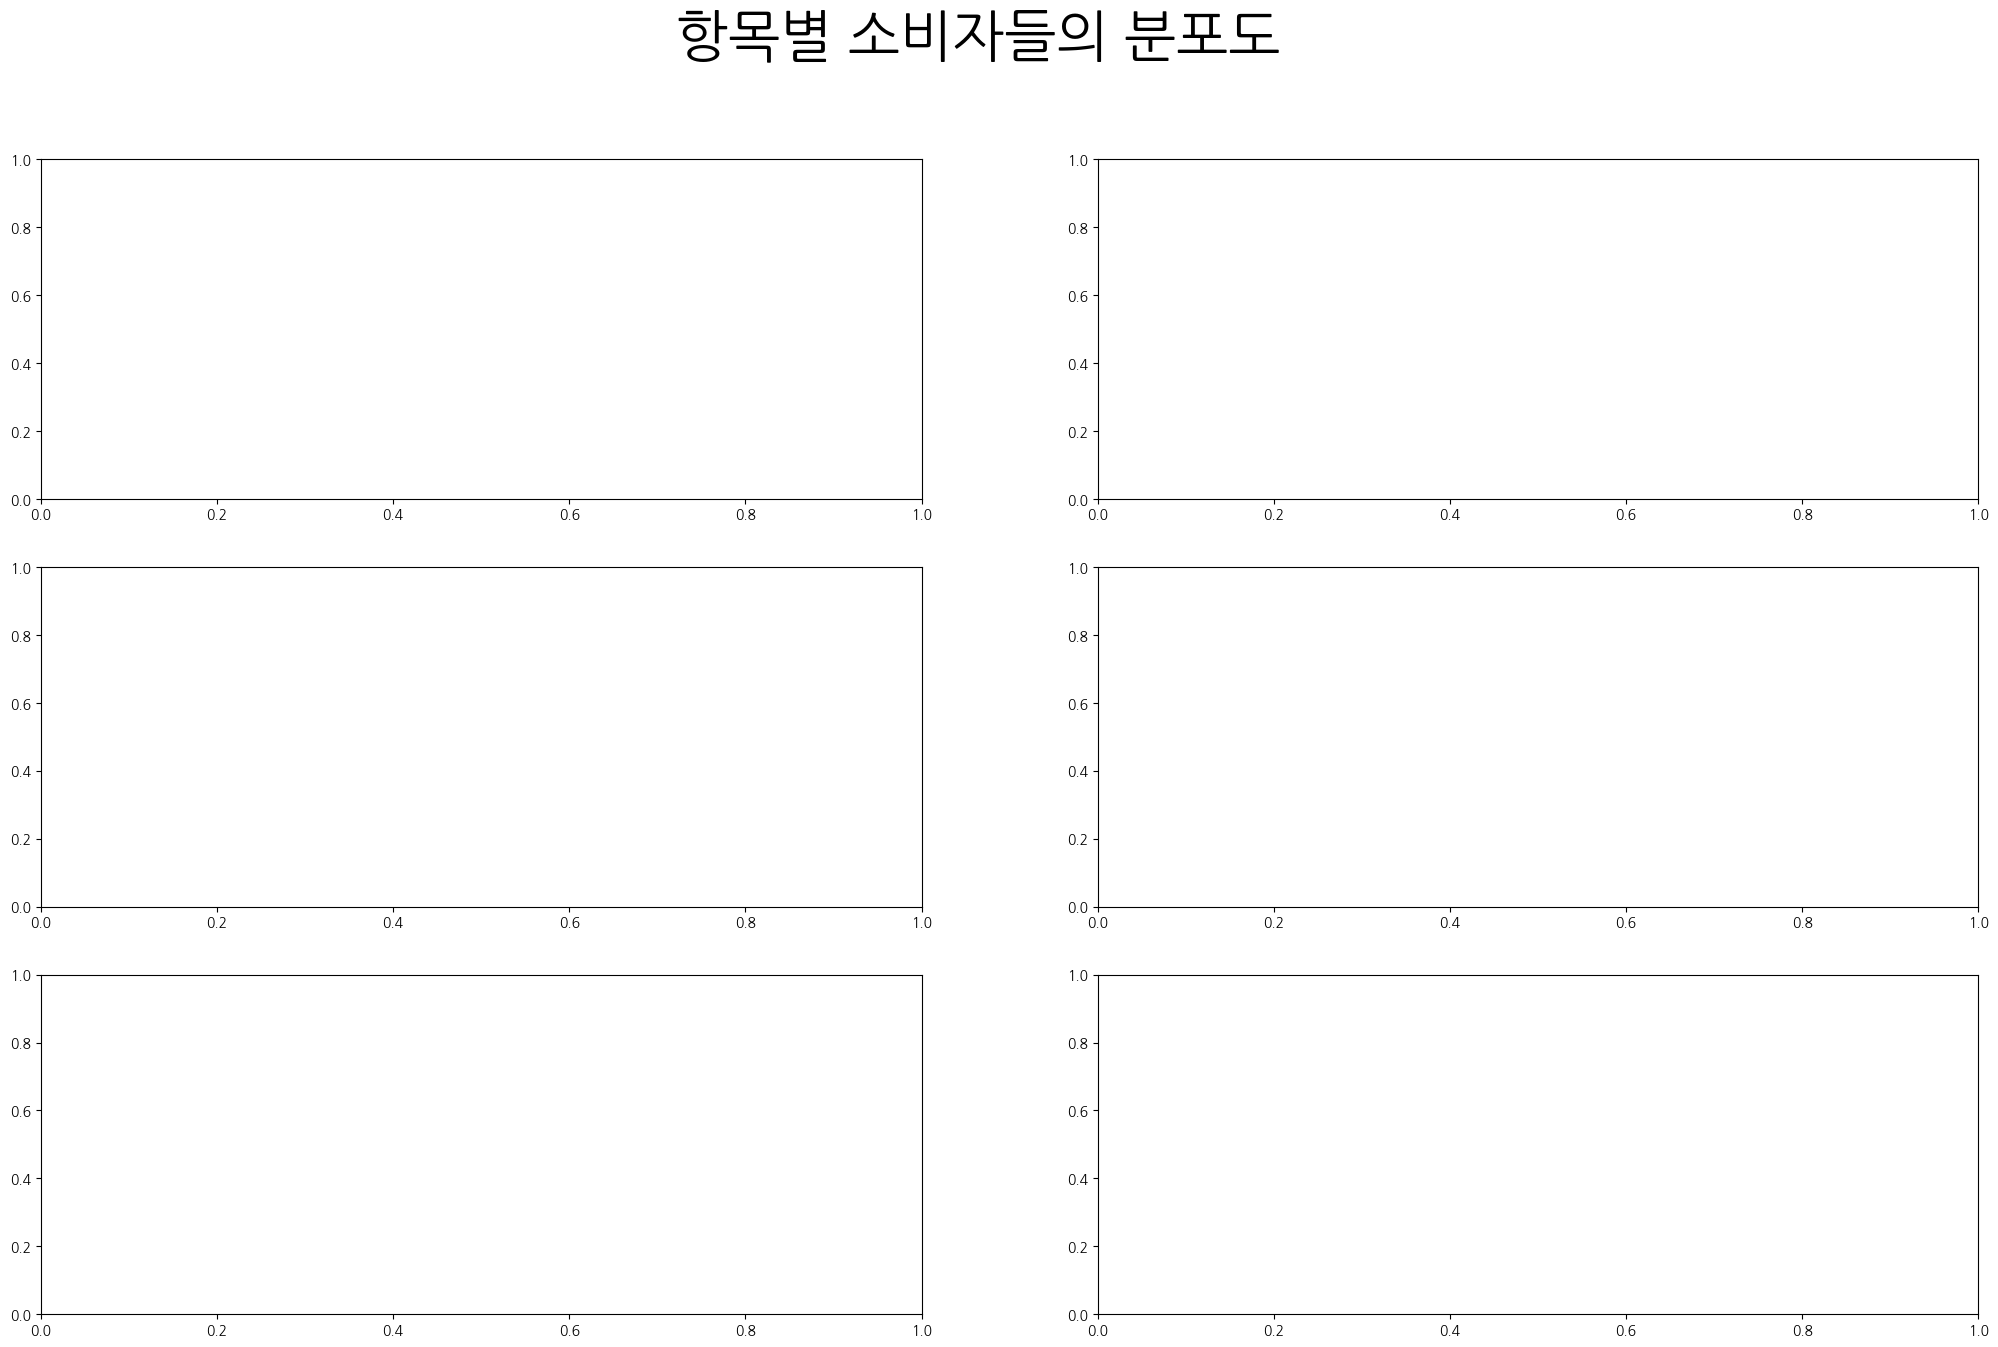

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(25,15))   # 한 번에 여러 그래프 plot
# fig: 전체 subplot, axs: 전체 중 각각의 그래프

fig.suptitle('항목별 소비자들의 분포도', fontsize=40)

In [ ]:
yticks = [50000, 100000, 150000, 200000, 250000]
axes0_ylabel = ['5만', '10만', '15만', '20만', '25만']

loc_code = df.groupby('시도코드').size().reset_index()
loc_code.rename(columns={0: 'count'}, inplace=True)
loc_code['시도코드'] = loc_code['시도코드'].astype('str') # inplace 없음
loc_code

axes[0][0].bar(loc_code['시도코드'], loc_code['count'], color='orange', alpha=0.5)
axes[0][0].set_title('시도별 인구 수')
axes[0][0].set_xlabel('시도코드')
axes[0][0].set_ylabel('인구 수')
axes[0][0].set_yticks(ticks=yticks, labels=axes0_ylabel)

In [ ]:
yticks = [100000, 200000, 300000, 400000, 500000]
axes1_ylabel = ['10만', '20만', '30만', '40만', '50만']

gender = df.groupby('성별코드').size().reset_index()
gender.rename(columns={0: 'count'}, inplace=True)
gender['성별코드'] = gender['성별코드'].astype('str') # inplace 없음
gender

axes[1][0].bar(gender['성별코드'], gender['count'], color='yellow', alpha=0.1)
axes[1][0].set_title('성별별 인구 수')
axes[1][0].set_xlabel('성별코드')
axes[1][0].set_ylabel('인구 수')
axes[1][0].set_yticks(ticks=yticks, labels=axes0_ylabel)

In [ ]:
hearing = df.groupby('청력(좌)').size().reset_index()
hearing.rename(columns={0: 'count'}, inplace=True)
hearing['청력(좌)'] = hearing['청력(좌)'].astype('str') # inplace 없음
hearing

axes[2][0].bar(hearing['청력(좌)'], hearing['count'], alpha=0.5, color='violet')
axes[2][0].set_title('청력(좌)별 인구 수')
axes[2][0].set_xlabel('청력')
axes[2][0].set_ylabel('인구 수')
axes[2][0].set_yticks(ticks=yticks, labels=axes0_ylabel)

In [ ]:
yticks = [200000, 400000, 600000, 800000, 1000000]
axes0_ylabel = ['20만', '40만', '60만', '80만', '100만']

hearing = df.groupby('청력(우)').size().reset_index()
hearing.rename(columns={0: 'count'}, inplace=True)
hearing['청력(우)'] = hearing['청력(우)'].astype('str') # inplace 없음
hearing

axes[2][0].bar(hearing['청력(우)'], hearing['count'], alpha=0.5, color='brown')
axes[2][0].set_title('청력(우)별 인구 수')
axes[2][0].set_xlabel('청력(우)')
axes[2][0].set_ylabel('인구 수')
axes[2][0].set_yticks(ticks=yticks, labels=axes0_ylabel)

In [ ]:
yticks = [20000, 40000, 60000, 80000, 100000, 120000]
axes0_ylabel = ['2만', '4만', '6만', '8만', '10만', '12만']

age = df.groupby('연령대코드(5세단위)').size().reset_index()
age.rename(columns={0: 'count'}, inplace=True)
age['연령대코드(5세단위)'] = age['연령대코드(5세단위)'].astype('str') # inplace 없음
age

axes[0][1].bar(age['연령대코드(5세단위)'], age['count'], alpha=0.5, color='skyblue')
axes[0][1].set_title('연령대별 인구 수')
axes[0][1].set_xlabel('나이')
axes[0][1].set_ylabel('인구 수')
axes[0][1].set_yticks(ticks=yticks, labels=axes0_ylabel)

In [ ]:
# 연령대별 식전혈당 분포

axes[1][1].scatter(df['연령대코드(5세단위)'], df['식전혈당(공복혈당)'], alpha=0.5, color='pink')
axes[1][1].set_title('연령대별 식전혈당 분포')
axes[1][1].set_xlabel('나이')
axes[1][1].set_ylabel('식전혈당')

Text(1061.2626262626259, 0.5, '식전혈당')

In [ ]:
# 연령대별 식전혈당 분포

axes[2][1].scatter(df['체중(5kg단위)'], df['식전혈당(공복혈당)'], color='grey')
axes[2][1].set_title('체중별 식전혈당 분포')
axes[2][1].set_xlabel('체중')
axes[2][1].set_ylabel('식전혈당')

Text(1061.2626262626259, 0.5, '식전혈당')

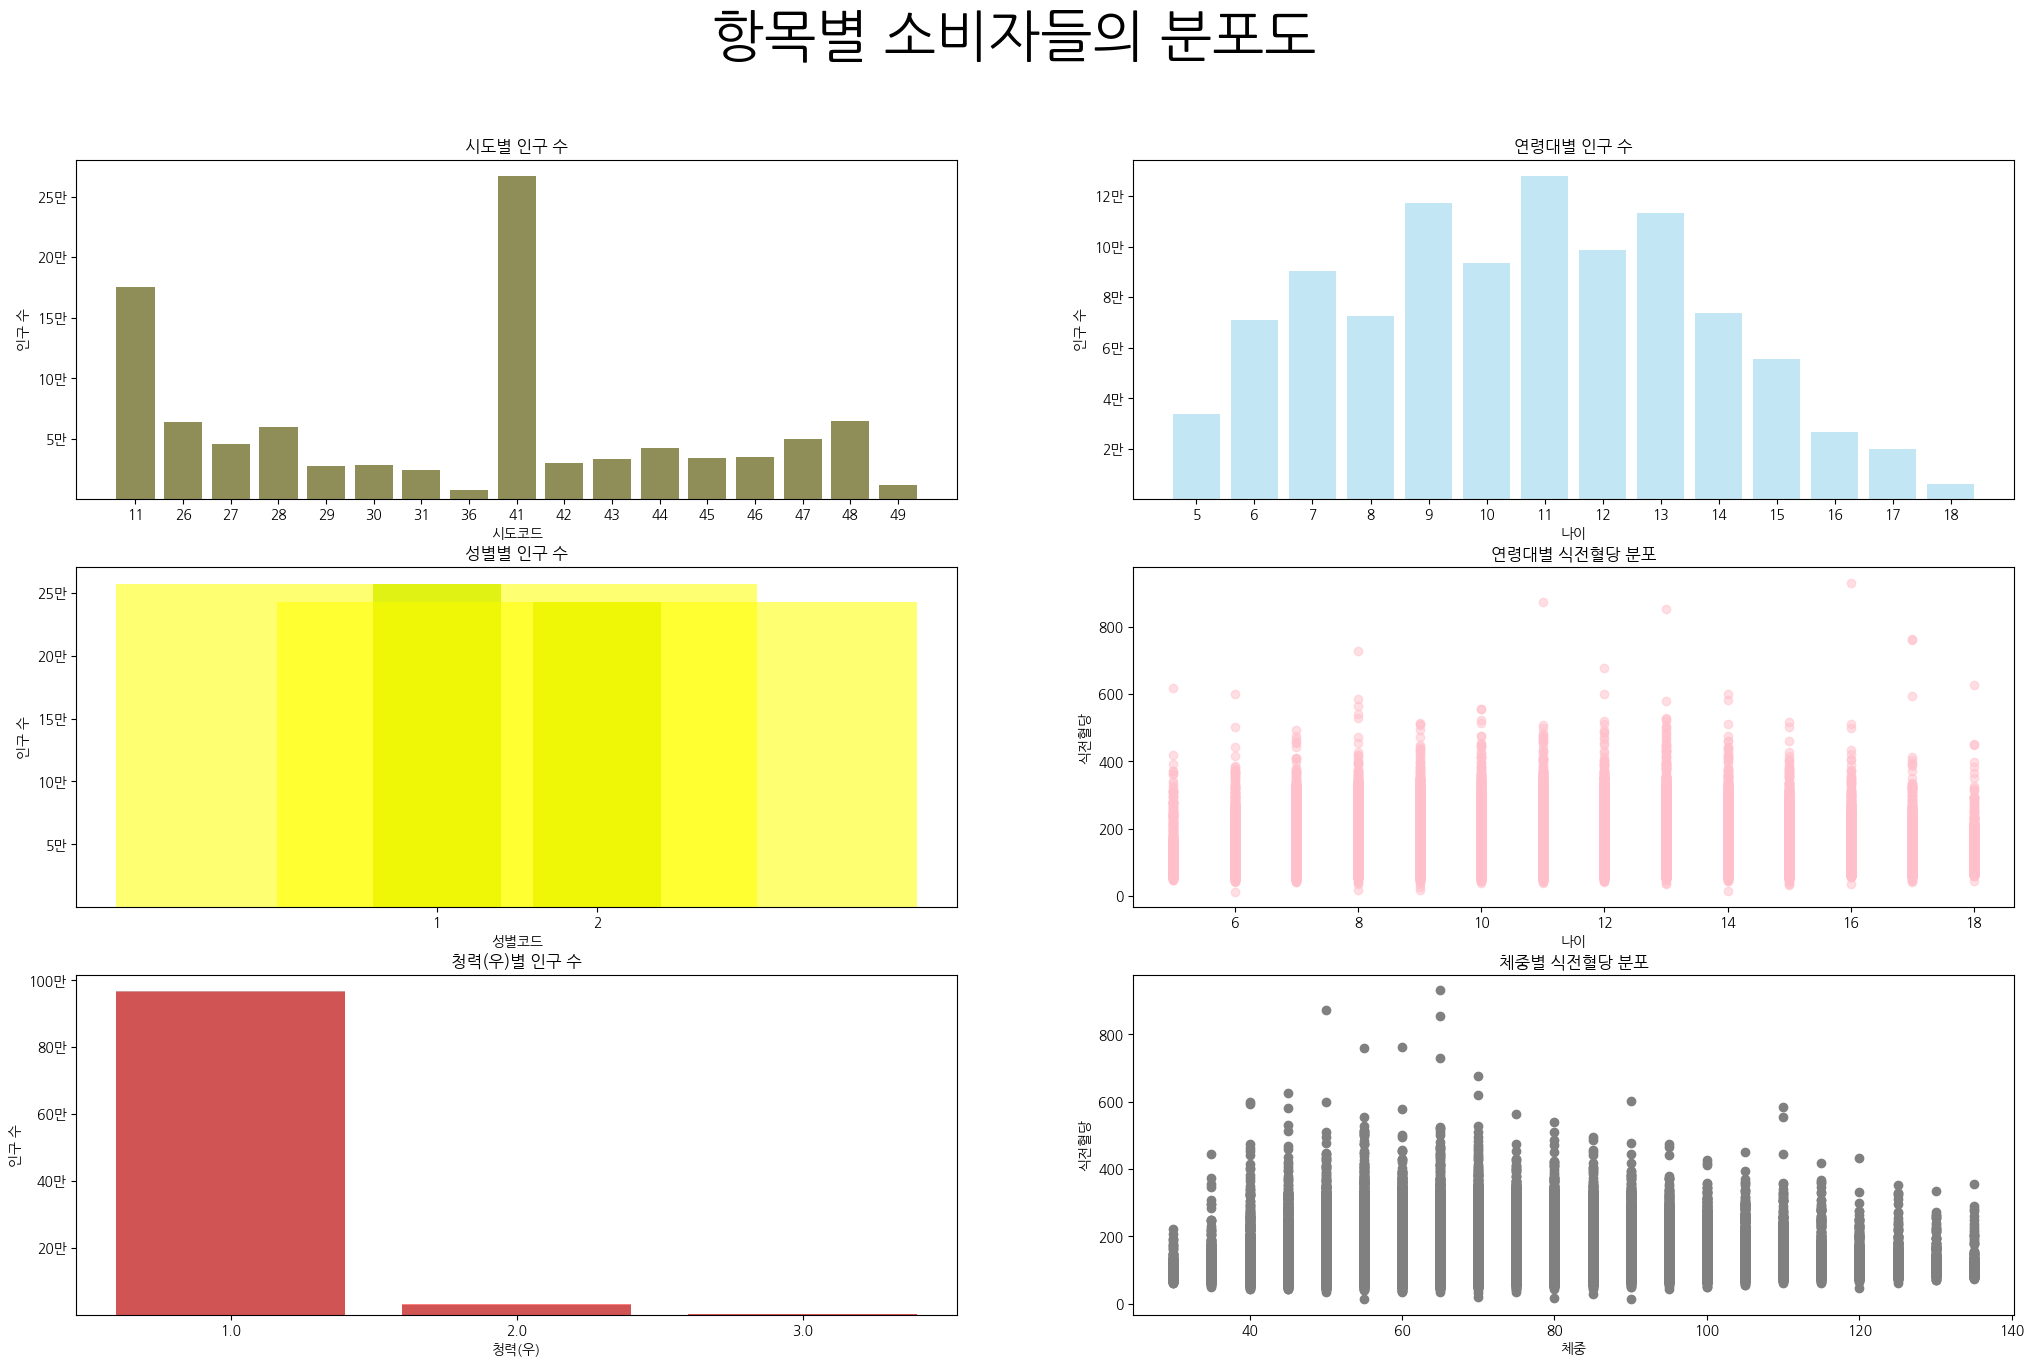

In [ ]:
fig